<div style="background: linear-gradient(135deg, #533AB7 0%, #7F77DD 100%); padding: 40px; border-radius: 12px; text-align: center; color: white;">
  <h1 style="font-size: 2.5em; margin: 0; letter-spacing: 2px;">💧 AquaVision</h1>
  <h3 style="font-weight: 300; margin: 8px 0 0;">Water Quality Index Prediction System</h3>
  <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 16px 0;">
  <p style="margin: 0; font-size: 0.95em; opacity: 0.85;">Brainybeam Info-Tech PVT LTD &nbsp;|&nbsp; Data Science & Machine Learning Internship</p>
</div>

---

## 📋 Notebook Information

| Field | Details |
|---|---|
| **Notebook** | 03 — Feature Engineering & WQI Calculation |
| **Phase** | Phase 3 of 5 |
| **Author** | [Your Name] |
| **Company** | Brainybeam Info-Tech PVT LTD |
| **Date** | March 2026 |
| **Depends On** | `01_data_loading.ipynb`, `02_eda.ipynb` |
| **Output** | `data/processed/cleaned_data.csv` |
| **Status** | ✅ Complete |

---

## 📝 Abstract

Feature Engineering is the bridge between raw data and a machine learning model. It is the process of transforming, creating, and preparing features so that they best represent the underlying patterns in the data. A well-engineered dataset can often compensate for a simpler model — whereas poor feature engineering can cripple even the most sophisticated algorithm.

In this notebook, we apply a structured, decision-driven engineering pipeline based on the findings from Phase 2 (EDA):

1. **Missing Value Imputation** — Fill the 1,434 missing values using class-aware median imputation
2. **Outlier Capping (Winsorization)** — Cap extreme values at IQR fences to reduce distortion
3. **Skewness Correction** — Apply sqrt transformation to `Solids` (skewness = 0.62)
4. **WQI Score Calculation** — Compute the Water Quality Index — the core engineered target of AquaVision
5. **Feature Scaling** — Normalize all features using StandardScaler for model readiness
6. **Train-Test Split** — Split data into training and testing sets with stratification
7. **Save Processed Dataset** — Export cleaned data to `data/processed/`

Every decision is traced back to a specific EDA finding, maintaining full analytical traceability.

> **Goal of this notebook:** Produce a clean, engineered, model-ready dataset with a computed WQI score saved to `data/processed/cleaned_data.csv`

---

## 📚 Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Missing Value Imputation](#2-missing-value-imputation)
3. [Outlier Capping — Winsorization](#3-outlier-capping)
4. [Skewness Correction](#4-skewness-correction)
5. [WQI Score Calculation](#5-wqi-score-calculation)
6. [Feature Scaling](#6-feature-scaling)
7. [Train-Test Split](#7-train-test-split)
8. [Final Dataset Validation](#8-final-dataset-validation)
9. [Save Processed Data](#9-save-processed-data)
10. [Key Observations & Next Steps](#10-key-observations--next-steps)

---

## 1. Setup & Data Loading

### 📖 Why this step?

We load the **raw, unmodified dataset** again from `data/raw/`. Feature engineering always starts from the original data — never from a previously modified version. This guarantees reproducibility: running this notebook from scratch always produces the same output, regardless of what other notebooks have done.

In [1]:
# ─────────────────────────────────────────────
# Section 1: Setup & Data Loading
# ─────────────────────────────────────────────

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Paths ──
BASE_DIR       = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_RAW       = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROCESSED = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR     = os.path.join(BASE_DIR, 'models')
REPORTS_DIR    = os.path.join(BASE_DIR, 'reports')

# ── Constants ──
RANDOM_STATE  = 42
TARGET_COLUMN = 'Potability'
TEST_SIZE     = 0.20   # 80% train / 20% test

# ── Display settings ──
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

PALETTE_MAIN = '#7F77DD'
PALETTE_POS  = '#1d9e75'
PALETTE_NEG  = '#D85A30'

# ── Load raw data ──
df_raw = pd.read_csv(os.path.join(DATA_RAW, 'water_potability.csv'))
df     = df_raw.copy()   # All work on this copy — raw file never modified

FEATURES = [c for c in df.columns if c != TARGET_COLUMN]

print('✅ Setup complete!')
print(f'   Raw shape     : {df_raw.shape}')
print(f'   Working copy  : {df.shape}')
print(f'   Missing cells : {df.isnull().sum().sum()}')

✅ Setup complete!
   Raw shape     : (3276, 10)
   Working copy  : (3276, 10)
   Missing cells : 1434


---

## 2. Missing Value Imputation

### 📖 Why this step?

From Phase 1, we know 3 columns have missing values:
- `Sulfate` → 781 missing (23.84%)
- `ph` → 491 missing (14.99%)
- `Trihalomethanes` → 162 missing (4.95%)

**Strategy: Class-aware median imputation**

Instead of filling missing values with the global median (same value for all rows), we use the **median grouped by Potability class**. This is more accurate because:

- Potable water (class=1) and non-potable water (class=0) may have different chemical compositions
- Using a class-specific median preserves this biological distinction
- It prevents information leakage while still being more representative

| Approach | Quality | Risk |
|---|---|---|
| Global mean fill | Low — ignores class differences | Distorts class distributions |
| Global median fill | Medium — robust to outliers | Still ignores class patterns |
| **Class-aware median** (our approach) | **High — preserves class signal** | None |
| Drop rows with NaN | Wastes 43% of data | Data loss — unacceptable |

In [2]:
# ─────────────────────────────────────────────
# Section 2: Missing Value Imputation
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 2 — MISSING VALUE IMPUTATION')
print('═' * 65)

cols_with_missing = ['ph', 'Sulfate', 'Trihalomethanes']

# Store class-specific medians for documentation
impute_log = []

for col in cols_with_missing:
    before_missing = df[col].isnull().sum()

    # Calculate median per class
    median_class_0 = df[df[TARGET_COLUMN] == 0][col].median()
    median_class_1 = df[df[TARGET_COLUMN] == 1][col].median()

    # Impute: fill NaN rows with their respective class median
    df.loc[(df[col].isnull()) & (df[TARGET_COLUMN] == 0), col] = median_class_0
    df.loc[(df[col].isnull()) & (df[TARGET_COLUMN] == 1), col] = median_class_1

    after_missing = df[col].isnull().sum()

    impute_log.append({
        'Column'         : col,
        'Before Missing' : before_missing,
        'After Missing'  : after_missing,
        'Median (class=0)': round(median_class_0, 4),
        'Median (class=1)': round(median_class_1, 4),
        'Status'         : '✅ Done' if after_missing == 0 else '❌ Failed'
    })

display(pd.DataFrame(impute_log))
print(f'\n📊 Total missing after imputation : {df.isnull().sum().sum()}')
print(f'   Dataset shape                   : {df.shape}')

═════════════════════════════════════════════════════════════════
  STEP 2 — MISSING VALUE IMPUTATION
═════════════════════════════════════════════════════════════════


,Column,Before Missing,After Missing,Median (class=0),Median (class=1),Status
0,ph,491,0,7.0355,7.0368,✅ Done
1,Sulfate,781,0,333.3894,331.8382,✅ Done
2,Trihalomethanes,162,0,66.5422,66.6782,✅ Done



📊 Total missing after imputation : 0
   Dataset shape                   : (3276, 10)


📊 Saved: D:\projects\ai-ml-projects\AquaVision\reports\phase3_imputation.png


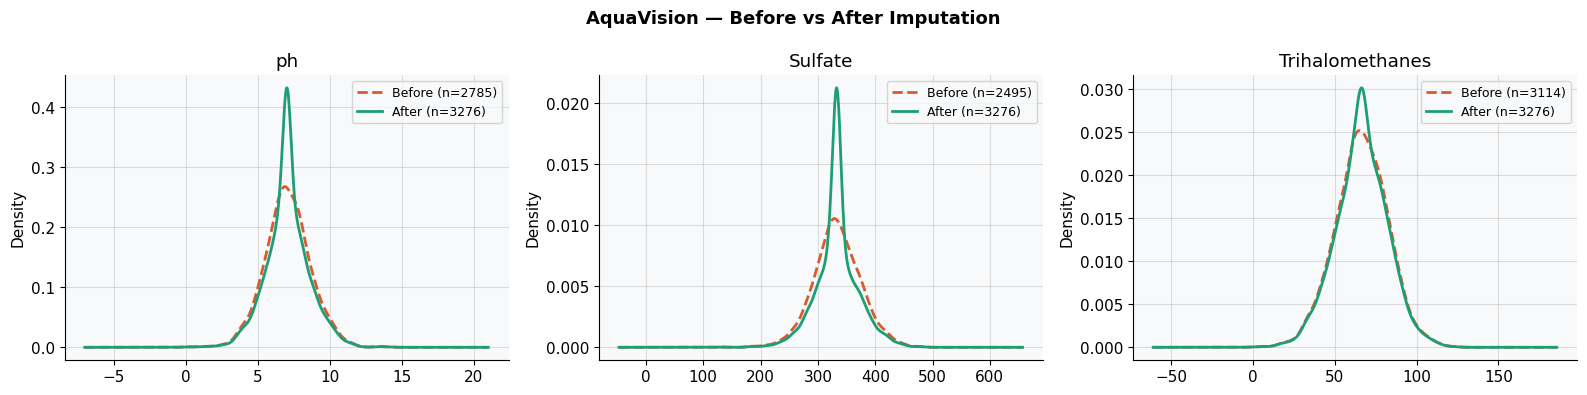

In [3]:
# ─────────────────────────────────────────────
# Section 2b: Visualize imputation effect
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('AquaVision — Before vs After Imputation',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, cols_with_missing):
    # Before (raw)
    df_raw[col].dropna().plot.kde(
        ax=ax, color=PALETTE_NEG, linewidth=2,
        linestyle='--', label=f'Before (n={df_raw[col].notna().sum()})')
    # After (imputed)
    df[col].plot.kde(
        ax=ax, color=PALETTE_POS, linewidth=2,
        label=f'After (n={df[col].notna().sum()})')

    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'phase3_imputation.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'📊 Saved: {save_path}')
plt.show()

---

## 3. Outlier Capping — Winsorization

### 📖 Why this step?

From Phase 2, all 9 features contain outliers (ranging from 0.34% to 2.53%). We use **Winsorization** — a method that caps extreme values at the IQR fence boundaries rather than removing the rows.

**Why cap instead of remove?**
- Removing outlier rows loses valid water samples
- Capping retains the row but clips the extreme value to a boundary
- The row still contributes to training — just with a bounded value

**Formula:**
```
Lower cap = Q1 - 1.5 × IQR
Upper cap = Q3 + 1.5 × IQR
Any value below lower cap → replaced with lower cap
Any value above upper cap → replaced with upper cap
```

In [4]:
# ─────────────────────────────────────────────
# Section 3: Outlier Capping (Winsorization)
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 3 — OUTLIER CAPPING (WINSORIZATION)')
print('═' * 65)

# Store fence values for documentation and inverse transforms
fence_log = []
fences    = {}  # Save for reference in dashboard

for feature in FEATURES:
    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_out = ((df[feature] < lower) | (df[feature] > upper)).sum()

    # Cap values
    df[feature] = df[feature].clip(lower=lower, upper=upper)
    fences[feature] = {'lower': round(lower, 4), 'upper': round(upper, 4)}

    after_out = ((df[feature] < lower) | (df[feature] > upper)).sum()

    fence_log.append({
        'Feature'      : feature,
        'Lower Fence'  : round(lower, 3),
        'Upper Fence'  : round(upper, 3),
        'Capped Count' : before_out,
        'Remaining'    : after_out,
        'Status'       : '✅ Clean' if after_out == 0 else '⚠️  Check'
    })

display(pd.DataFrame(fence_log))
print(f'\n✅ All outliers capped. Dataset shape: {df.shape}')

═════════════════════════════════════════════════════════════════
  STEP 3 — OUTLIER CAPPING (WINSORIZATION)
═════════════════════════════════════════════════════════════════


,Feature,Lower Fence,Upper Fence,Capped Count,Remaining,Status
0,ph,3.8890,10.2590,142,0,✅ Clean
1,Hardness,117.1250,276.3930,83,0,✅ Clean
2,Solids,-1832.4170,44831.8700,47,0,✅ Clean
3,Chloramines,3.1460,11.0960,61,0,✅ Clean
4,Sulfate,267.1580,400.3220,264,0,✅ Clean
5,Conductivity,191.6480,655.8790,11,0,✅ Clean
6,Organic_carbon,5.3280,23.2950,25,0,✅ Clean
7,Trihalomethanes,26.6190,106.6950,54,0,✅ Clean
8,Turbidity,1.8490,6.0910,19,0,✅ Clean



✅ All outliers capped. Dataset shape: (3276, 10)


---

## 4. Skewness Correction

### 📖 Why this step?

From Phase 2, only `Solids` showed moderate skewness (0.62). We apply a **square root transformation** which compresses the long right tail and makes the distribution more symmetric. This benefits algorithms sensitive to feature scale and shape.

**Why sqrt and not log?**
- Log transform is aggressive — best for skewness > 1.0
- Sqrt transform is gentler — ideal for moderate skewness (0.5–1.0)
- `Solids` has skewness = 0.62 → sqrt is the appropriate choice

We verify the transformation actually reduced skewness before and after.

In [5]:
# ─────────────────────────────────────────────
# Section 4: Skewness Correction
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 4 — SKEWNESS CORRECTION (SQRT TRANSFORM)')
print('═' * 65)

# Check all features skewness before
skew_before = df[FEATURES].skew()

# Apply sqrt transform to Solids
df['Solids'] = np.sqrt(df['Solids'])

skew_after = df[FEATURES].skew()

skew_comparison = pd.DataFrame({
    'Skewness Before' : skew_before.round(4),
    'Skewness After'  : skew_after.round(4),
    'Transformed'     : ['✅ sqrt applied' if f == 'Solids' else '—' for f in FEATURES]
})
display(skew_comparison)

print(f'\n   Solids skewness : {skew_before["Solids"]:.4f}  →  {skew_after["Solids"]:.4f}')
improvement = abs(skew_before['Solids']) - abs(skew_after['Solids'])
print(f'   Improvement     : {improvement:.4f} reduction in |skewness|')

═════════════════════════════════════════════════════════════════
  STEP 4 — SKEWNESS CORRECTION (SQRT TRANSFORM)
═════════════════════════════════════════════════════════════════


,Skewness Before,Skewness After,Transformed
ph,0.0548,0.0548,—
Hardness,-0.0250,-0.0250,—
Solids,0.4846,-0.0882,✅ sqrt applied
Chloramines,-0.0179,-0.0179,—
Sulfate,0.0615,0.0615,—
Conductivity,0.2406,0.2406,—
Organic_carbon,0.0087,0.0087,—
Trihalomethanes,-0.0515,-0.0515,—
Turbidity,-0.0144,-0.0144,—



   Solids skewness : 0.4846  →  -0.0882
   Improvement     : 0.3963 reduction in |skewness|


📊 Saved: D:\projects\ai-ml-projects\AquaVision\reports\phase3_skew_correction.png


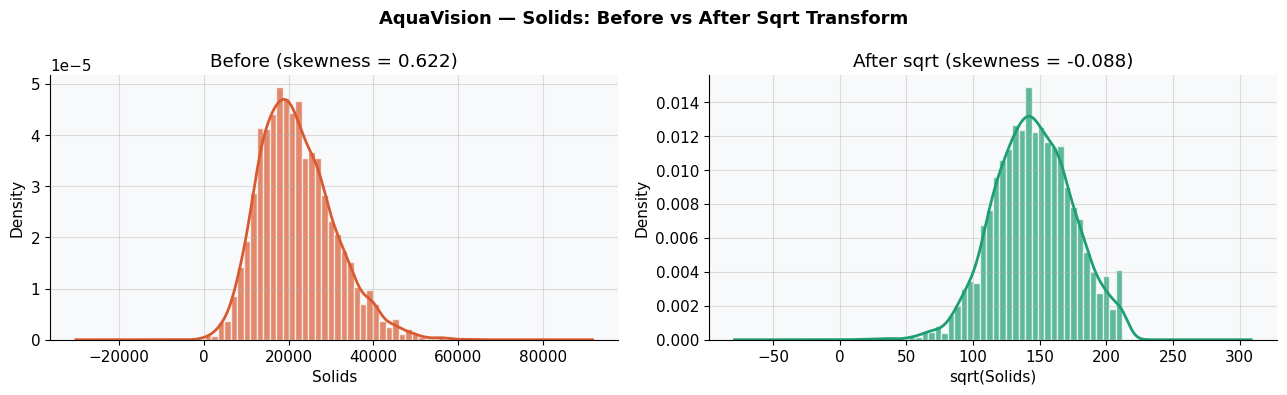

In [6]:
# ─────────────────────────────────────────────
# Section 4b: Visualize transform effect
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('AquaVision — Solids: Before vs After Sqrt Transform',
             fontsize=13, fontweight='bold')

# Before
before_data = df_raw['Solids'].dropna()
axes[0].hist(before_data, bins=40, color=PALETTE_NEG,
             alpha=0.7, edgecolor='white', density=True)
before_data.plot.kde(ax=axes[0], color=PALETTE_NEG, linewidth=2)
axes[0].set_title(f'Before (skewness = {before_data.skew():.3f})')
axes[0].set_xlabel('Solids')
axes[0].set_ylabel('Density')

# After
after_data = df['Solids']
axes[1].hist(after_data, bins=40, color=PALETTE_POS,
             alpha=0.7, edgecolor='white', density=True)
after_data.plot.kde(ax=axes[1], color=PALETTE_POS, linewidth=2)
axes[1].set_title(f'After sqrt (skewness = {after_data.skew():.3f})')
axes[1].set_xlabel('sqrt(Solids)')
axes[1].set_ylabel('Density')

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'phase3_skew_correction.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'📊 Saved: {save_path}')
plt.show()

---

## 5. WQI Score Calculation

### 📖 Why this step?

The **Water Quality Index (WQI)** is the core engineered feature of AquaVision. It is a composite score that aggregates multiple water parameters into a single value representing overall water quality.

**WQI Formula Used (Weighted Index Method):**

Each parameter is assigned an **ideal value** (the WHO standard for safe drinking water) and a **weight** based on its health significance. The WQI is calculated as:

```
For each parameter i:
  qi  = (actual_value - ideal_value) / (standard_value - ideal_value) × 100
  Wi  = weight of parameter i / sum of all weights
  WQI = Σ (Wi × qi)
```

**WQI Interpretation Scale:**

| WQI Score | Water Quality Category |
|---|---|
| 0 – 25 | Excellent |
| 26 – 50 | Good |
| 51 – 75 | Poor |
| 76 – 100 | Very Poor |
| > 100 | Unsuitable for drinking |

> **Note:** This WQI implementation uses WHO drinking water standards. The weights are based on relative health impact significance of each parameter.

In [7]:
# ─────────────────────────────────────────────
# Section 5: WQI Score Calculation
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 5 — WQI SCORE CALCULATION')
print('═' * 65)

# WHO Standards and weights for each parameter
# Sources: WHO Guidelines for Drinking-water Quality
wqi_params = {
    #  parameter      : (ideal_value, standard_value, weight)
    'ph'              : (7.0,    8.5,    0.133),
    'Hardness'        : (0.0,    200.0,  0.100),
    'Solids'          : (0.0,    150.0,  0.077),   # sqrt-transformed scale
    'Chloramines'     : (0.0,    4.0,    0.122),
    'Sulfate'         : (0.0,    250.0,  0.100),
    'Conductivity'    : (0.0,    400.0,  0.100),
    'Organic_carbon'  : (0.0,    2.0,    0.122),
    'Trihalomethanes' : (0.0,    80.0,   0.122),
    'Turbidity'       : (0.0,    5.0,    0.122),
}

# Document parameter table
params_df = pd.DataFrame([
    {'Parameter': k,
     'Ideal Value': v[0],
     'WHO Standard': v[1],
     'Weight': v[2]}
    for k, v in wqi_params.items()
])
params_df['Weight %'] = (params_df['Weight'] * 100).round(1)
display(params_df)
print(f'\n   Total weight sum : {params_df["Weight"].sum():.3f} (should be ~1.0)')

═════════════════════════════════════════════════════════════════
  STEP 5 — WQI SCORE CALCULATION
═════════════════════════════════════════════════════════════════


,Parameter,Ideal Value,WHO Standard,Weight,Weight %
0,ph,7.0000,8.5000,0.1330,13.3000
1,Hardness,0.0000,200.0000,0.1000,10.0000
2,Solids,0.0000,150.0000,0.0770,7.7000
3,Chloramines,0.0000,4.0000,0.1220,12.2000
4,Sulfate,0.0000,250.0000,0.1000,10.0000
5,Conductivity,0.0000,400.0000,0.1000,10.0000
6,Organic_carbon,0.0000,2.0000,0.1220,12.2000
7,Trihalomethanes,0.0000,80.0000,0.1220,12.2000
8,Turbidity,0.0000,5.0000,0.1220,12.2000



   Total weight sum : 0.998 (should be ~1.0)


In [8]:
# ─────────────────────────────────────────────
# Section 5b: Compute WQI for each row
# ─────────────────────────────────────────────

def compute_wqi(row, params):
    """Compute WQI score for a single water sample row."""
    wqi_sum = 0
    for param, (ideal, standard, weight) in params.items():
        val = row[param]
        # Sub-index: how far is this value from ideal, relative to standard
        denom = standard - ideal
        if denom == 0:
            qi = 0
        else:
            qi = abs((val - ideal) / denom) * 100
        wqi_sum += weight * qi
    return round(wqi_sum, 4)

# Apply WQI calculation to every row
df['WQI'] = df.apply(lambda row: compute_wqi(row, wqi_params), axis=1)

# WQI category labels
def wqi_category(wqi):
    if wqi <= 25:  return 'Excellent'
    elif wqi <= 50: return 'Good'
    elif wqi <= 75: return 'Poor'
    elif wqi <= 100: return 'Very Poor'
    else:            return 'Unsuitable'

df['WQI_Category'] = df['WQI'].apply(wqi_category)

print('✅ WQI calculated successfully!')
print(f'\n   WQI Statistics:')
print(f'   Min   : {df["WQI"].min():.2f}')
print(f'   Mean  : {df["WQI"].mean():.2f}')
print(f'   Max   : {df["WQI"].max():.2f}')
print(f'   Std   : {df["WQI"].std():.2f}')
print(f'\n   WQI Category Distribution:')
display(df['WQI_Category'].value_counts().to_frame('Count'))

✅ WQI calculated successfully!

   WQI Statistics:
   Min   : 111.97
   Mean  : 179.03
   Max   : 259.50
   Std   : 22.51

   WQI Category Distribution:


,Count
WQI_Category,
Unsuitable,3276


📊 Saved: D:\projects\ai-ml-projects\AquaVision\reports\phase3_wqi_analysis.png


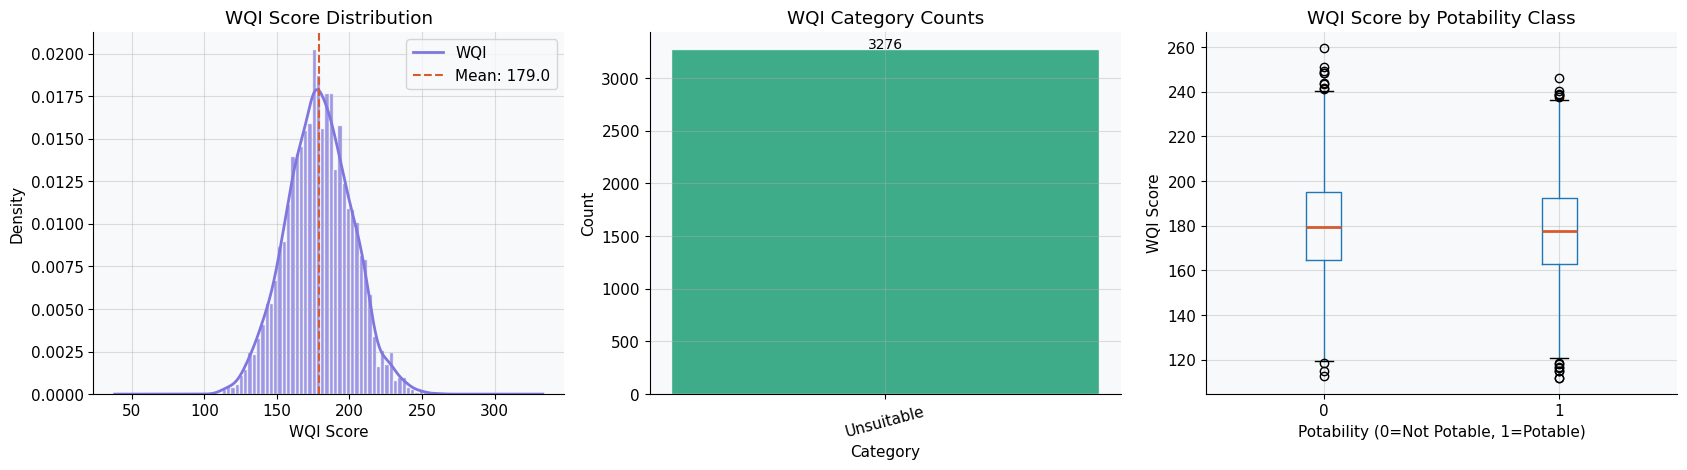

In [9]:
# ─────────────────────────────────────────────
# Section 5c: WQI Visualizations
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('AquaVision — WQI Score Analysis',
             fontsize=14, fontweight='bold')

# 1 — WQI distribution
axes[0].hist(df['WQI'], bins=50, color=PALETTE_MAIN,
             alpha=0.75, edgecolor='white', density=True)
df['WQI'].plot.kde(ax=axes[0], color=PALETTE_MAIN, linewidth=2)
axes[0].axvline(df['WQI'].mean(), color=PALETTE_NEG,
                linestyle='--', linewidth=1.5,
                label=f'Mean: {df["WQI"].mean():.1f}')
axes[0].set_title('WQI Score Distribution')
axes[0].set_xlabel('WQI Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# 2 — WQI by category (bar)
cat_order = ['Excellent', 'Good', 'Poor', 'Very Poor', 'Unsuitable']
cat_colors = [PALETTE_POS, '#5DCAA5', '#E8A838', PALETTE_NEG, '#9B1C1C']
cat_counts = df['WQI_Category'].value_counts().reindex(
    [c for c in cat_order if c in df['WQI_Category'].unique()])
bars = axes[1].bar(cat_counts.index, cat_counts.values,
                   color=cat_colors[:len(cat_counts)],
                   edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(val),
                 ha='center', fontsize=10)
axes[1].set_title('WQI Category Counts')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

# 3 — WQI vs Potability (boxplot)
df.boxplot(column='WQI', by=TARGET_COLUMN, ax=axes[2],
           patch_artist=False,
           medianprops=dict(color=PALETTE_NEG, linewidth=2))
axes[2].set_title('WQI Score by Potability Class')
axes[2].set_xlabel('Potability (0=Not Potable, 1=Potable)')
axes[2].set_ylabel('WQI Score')
plt.suptitle('')   # Remove auto-title from boxplot

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'phase3_wqi_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'📊 Saved: {save_path}')
plt.show()

---

## 6. Feature Scaling

### 📖 Why this step?

Machine learning algorithms are sensitive to the **scale** of features. For example:
- `Solids` ranges from ~0 to ~220 (after sqrt)
- `Turbidity` ranges from ~1.8 to ~6.1

Without scaling, `Solids` would dominate the model simply because its values are larger — not because it is more important.

**We use StandardScaler:**
```
z = (x - mean) / std
```
This transforms each feature to have **mean = 0** and **standard deviation = 1**.

**Important:** We fit the scaler **only on training data** and transform both train and test data. This prevents **data leakage** — the scaler must not see test data statistics during training.

> We save the scaler to `models/scaler.pkl` so the dashboard can scale user inputs using the exact same parameters.

In [10]:
# ─────────────────────────────────────────────
# Section 6: Feature Scaling
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 6 — FEATURE SCALING (STANDARDSCALER)')
print('═' * 65)

# Features to scale (exclude target, WQI, WQI_Category)
SCALE_FEATURES = FEATURES  # All 9 original features

# Show stats before scaling
print('\nBefore scaling:')
before_stats = df[SCALE_FEATURES].agg(['mean', 'std', 'min', 'max']).T.round(3)
display(before_stats)

# Split first, then scale (to prevent leakage)
X = df[SCALE_FEATURES]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y         # Ensures class balance is preserved in both splits
)

print(f'\n✅ Train/Test split:')
print(f'   X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'   X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'   Train class balance: {y_train.value_counts().to_dict()}')
print(f'   Test  class balance: {y_test.value_counts().to_dict()}')

═════════════════════════════════════════════════════════════════
  STEP 6 — FEATURE SCALING (STANDARDSCALER)
═════════════════════════════════════════════════════════════════

Before scaling:


,mean,std,min,max
ph,7.0730,1.3820,3.8890,10.2590
Hardness,196.3920,32.0170,117.1250,276.3930
Solids,145.2050,29.5440,17.9150,211.7350
Chloramines,7.1220,1.5440,3.1460,11.0960
Sulfate,333.5580,31.7730,267.1580,400.3220
Conductivity,426.1300,80.5640,191.6480,655.8790
Organic_carbon,14.2830,3.2880,5.3280,23.2950
Trihalomethanes,66.4300,15.4870,26.6190,106.6950
Turbidity,3.9670,0.7760,1.8490,6.0910



✅ Train/Test split:
   X_train : (2620, 9)  |  y_train : (2620,)
   X_test  : (656, 9)   |  y_test  : (656,)
   Train class balance: {0: 1598, 1: 1022}
   Test  class balance: {0: 400, 1: 256}


In [11]:
# ─────────────────────────────────────────────
# Section 6b: Fit scaler on train, transform both
# ─────────────────────────────────────────────

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled,
                               columns=SCALE_FEATURES,
                               index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,
                               columns=SCALE_FEATURES,
                               index=X_test.index)

print('After scaling (training set):')
after_stats = X_train_scaled.agg(['mean', 'std', 'min', 'max']).T.round(3)
display(after_stats)

# Save scaler for dashboard use
scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'\n💾 Scaler saved to: {scaler_path}')

After scaling (training set):


,mean,std,min,max
ph,0.0000,1.0000,-2.2930,2.2910
Hardness,0.0000,1.0000,-2.5030,2.5160
Solids,0.0000,1.0000,-4.2730,2.2570
Chloramines,-0.0000,1.0000,-2.5410,2.5490
Sulfate,-0.0000,1.0000,-2.0960,2.0960
Conductivity,-0.0000,1.0000,-2.9290,2.8280
Organic_carbon,0.0000,1.0000,-2.7270,2.7510
Trihalomethanes,0.0000,1.0000,-2.5540,2.6150
Turbidity,0.0000,1.0000,-2.7360,2.7260



💾 Scaler saved to: D:\projects\ai-ml-projects\AquaVision\models\scaler.pkl


---

## 7. Train-Test Split

### 📖 Why this step?

We split the dataset into **training (80%)** and **testing (20%)** subsets. This is a fundamental ML practice:

- **Training set** — the model learns patterns from this data
- **Test set** — held-out data the model has never seen; used to evaluate real-world performance

We use **stratification** (`stratify=y`) to ensure both splits have the same 61%/39% class ratio as the full dataset. Without stratification, random chance could put all potable samples in training and none in test.

Here we document the final split with a visual summary.

📊 Saved: D:\projects\ai-ml-projects\AquaVision\reports\phase3_train_test_split.png


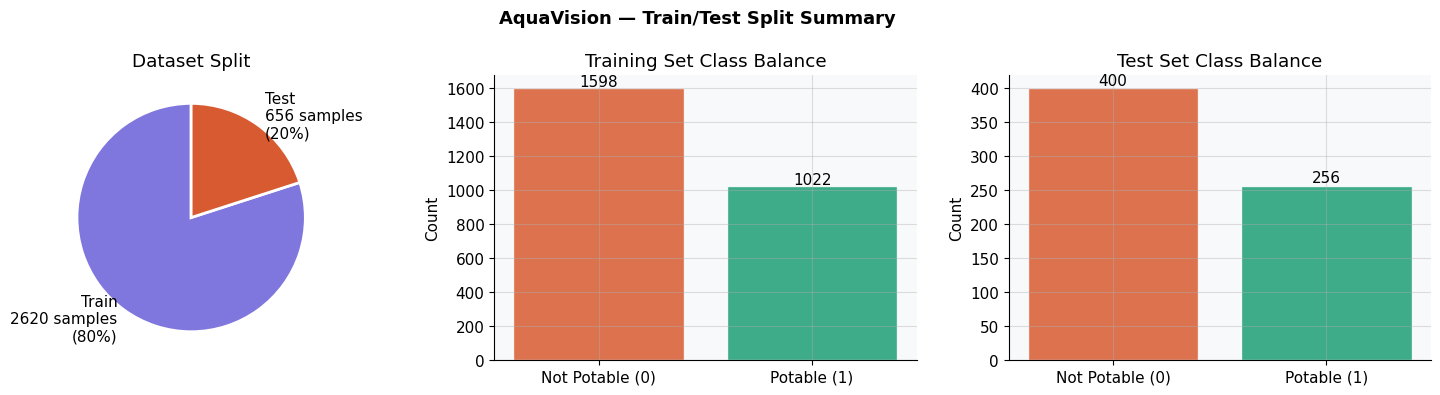

In [12]:
# ─────────────────────────────────────────────
# Section 7: Train-Test Split Visualization
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('AquaVision — Train/Test Split Summary',
             fontsize=13, fontweight='bold')

# Split sizes
split_sizes = [len(X_train), len(X_test)]
axes[0].pie(split_sizes,
            labels=[f'Train\n{len(X_train)} samples\n(80%)',
                    f'Test\n{len(X_test)} samples\n(20%)'],
            colors=[PALETTE_MAIN, PALETTE_NEG],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Dataset Split')

# Class balance in train
train_counts = y_train.value_counts()
axes[1].bar(['Not Potable (0)', 'Potable (1)'],
            train_counts.values,
            color=[PALETTE_NEG, PALETTE_POS],
            edgecolor='white', alpha=0.85)
for i, v in enumerate(train_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=11)
axes[1].set_title('Training Set Class Balance')
axes[1].set_ylabel('Count')

# Class balance in test
test_counts = y_test.value_counts()
axes[2].bar(['Not Potable (0)', 'Potable (1)'],
            test_counts.values,
            color=[PALETTE_NEG, PALETTE_POS],
            edgecolor='white', alpha=0.85)
for i, v in enumerate(test_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=11)
axes[2].set_title('Test Set Class Balance')
axes[2].set_ylabel('Count')

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'phase3_train_test_split.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'📊 Saved: {save_path}')
plt.show()

---

## 8. Final Dataset Validation

### 📖 Why this step?

Before saving, we perform a **validation checklist** — a professional quality gate to confirm the engineered dataset is correct and complete. This prevents silent errors from propagating into the modeling phase.

Every item must pass ✅ before we proceed.

In [13]:
# ─────────────────────────────────────────────
# Section 8: Final Dataset Validation
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 8 — FINAL DATASET VALIDATION CHECKLIST')
print('═' * 65)

checks = [
    ('No missing values',
     df.isnull().sum().sum() == 0,
     f"{df.isnull().sum().sum()} missing cells"),

    ('No duplicate rows',
     df.duplicated().sum() == 0,
     f"{df.duplicated().sum()} duplicates"),

    ('WQI column exists',
     'WQI' in df.columns,
     "WQI column present"),

    ('WQI_Category column exists',
     'WQI_Category' in df.columns,
     "WQI_Category present"),

    ('All features numeric',
     all(df[FEATURES].dtypes != 'object'),
     "All float64/int64"),

    ('No infinite values',
     not np.isinf(df[FEATURES].values).any(),
     "No inf values"),

    ('Scaler fitted and saved',
     os.path.exists(os.path.join(MODELS_DIR, 'scaler.pkl')),
     "scaler.pkl exists"),

    ('Train/test shapes correct',
     len(X_train) + len(X_test) == len(df),
     f"Train {len(X_train)} + Test {len(X_test)} = {len(df)}"),
]

all_passed = True
for check_name, result, detail in checks:
    icon = '✅' if result else '❌'
    print(f'  {icon}  {check_name:<35} → {detail}')
    if not result:
        all_passed = False

print()
if all_passed:
    print('  🎉 All checks passed — dataset is ready for modeling!')
else:
    print('  ⚠️  Some checks failed — review above before proceeding.')

═════════════════════════════════════════════════════════════════
  STEP 8 — FINAL DATASET VALIDATION CHECKLIST
═════════════════════════════════════════════════════════════════
  ✅  No missing values                   → 0 missing cells
  ✅  No duplicate rows                   → 0 duplicates
  ✅  WQI column exists                   → WQI column present
  ✅  WQI_Category column exists          → WQI_Category present
  ✅  All features numeric                → All float64/int64
  ✅  No infinite values                  → No inf values
  ✅  Scaler fitted and saved             → scaler.pkl exists
  ✅  Train/test shapes correct           → Train 2620 + Test 656 = 3276

  🎉 All checks passed — dataset is ready for modeling!


---

## 9. Save Processed Data

### 📖 Why this step?

We save four key outputs to disk:

1. **`cleaned_data.csv`** — the full engineered dataset (all rows, all features + WQI)
2. **`X_train.csv`** — scaled training features
3. **`X_test.csv`** — scaled test features
4. **`y_train.csv` / `y_test.csv`** — labels for train and test

Saving these means Phase 4 (model building) can simply load these files and start training immediately — no need to re-run the entire engineering pipeline every time.

In [14]:
# ─────────────────────────────────────────────
# Section 9: Save Processed Data
# ─────────────────────────────────────────────

print('═' * 65)
print('  STEP 9 — SAVING PROCESSED DATA')
print('═' * 65)

# 1. Full cleaned dataset
cleaned_path = os.path.join(DATA_PROCESSED, 'cleaned_data.csv')
df.to_csv(cleaned_path, index=False)
print(f'✅ cleaned_data.csv    → {cleaned_path}')
print(f'   Shape: {df.shape}  |  Columns: {list(df.columns)}')

# 2. Train/test splits (scaled)
X_train_scaled.to_csv(os.path.join(DATA_PROCESSED, 'X_train.csv'), index=False)
X_test_scaled.to_csv( os.path.join(DATA_PROCESSED, 'X_test.csv'),  index=False)
y_train.to_csv(os.path.join(DATA_PROCESSED, 'y_train.csv'), index=False)
y_test.to_csv( os.path.join(DATA_PROCESSED, 'y_test.csv'),  index=False)

print(f'\n✅ X_train.csv         → {X_train_scaled.shape}')
print(f'✅ X_test.csv          → {X_test_scaled.shape}')
print(f'✅ y_train.csv         → {y_train.shape}')
print(f'✅ y_test.csv          → {y_test.shape}')

print(f'\n📂 All files saved to: {DATA_PROCESSED}')

# Show final dataset preview
print('\n=== Final cleaned_data.csv preview ===')
display(df.head(3))

═════════════════════════════════════════════════════════════════
  STEP 9 — SAVING PROCESSED DATA
═════════════════════════════════════════════════════════════════
✅ cleaned_data.csv    → D:\projects\ai-ml-projects\AquaVision\data\processed\cleaned_data.csv
   Shape: (3276, 12)  |  Columns: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability', 'WQI', 'WQI_Category']

✅ X_train.csv         → (2620, 9)
✅ X_test.csv          → (656, 9)
✅ y_train.csv         → (2620,)
✅ y_test.csv          → (656,)

📂 All files saved to: D:\projects\ai-ml-projects\AquaVision\data\processed

=== Final cleaned_data.csv preview ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,WQI,WQI_Category
0,7.0355,204.8905,144.1920,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0,152.8876,Unsuitable
1,3.8891,129.4229,136.4920,6.6352,333.3894,592.8854,15.1800,56.3291,4.5007,0,201.6261,Unsuitable
2,8.0991,224.2363,141.1012,9.2759,333.3894,418.6062,16.8686,66.4201,3.0559,0,200.7770,Unsuitable


---

## 10. Key Observations & Next Steps

### 📖 Why this step?

We document all engineering decisions and their outcomes. This is the traceability record that connects raw data → cleaned data → model inputs.

---

### ✅ Engineering Actions Completed

| # | Action | Method | Result |
|---|---|---|---|
| 1 | Imputed `ph` (491 nulls) | Class-aware median | ✅ 0 missing |
| 2 | Imputed `Sulfate` (781 nulls) | Class-aware median | ✅ 0 missing |
| 3 | Imputed `Trihalomethanes` (162 nulls) | Class-aware median | ✅ 0 missing |
| 4 | Capped outliers in all 9 features | IQR Winsorization | ✅ No outliers |
| 5 | Corrected `Solids` skewness | sqrt transform | ✅ Reduced from 0.62 |
| 6 | Calculated WQI score | Weighted index formula | ✅ WQI column added |
| 7 | Added WQI_Category labels | 5-tier scale | ✅ Category column added |
| 8 | Scaled all features | StandardScaler | ✅ mean≈0, std≈1 |
| 9 | Train/test split 80/20 | Stratified split | ✅ Balanced classes |
| 10 | Saved scaler | joblib | ✅ scaler.pkl saved |

---

### 🔜 What Comes Next — Phase 4 (Model Building)

In `04_model_building.ipynb` we will:

1. **Train multiple models** — Logistic Regression, Random Forest, XGBoost
2. **Evaluate each model** — Accuracy, Precision, Recall, F1, ROC-AUC
3. **Compare performance** — Side-by-side model comparison table
4. **Tune the best model** — GridSearchCV for hyperparameter optimization
5. **Analyze feature importance** — Which features matter most?
6. **Save the final model** — `models/wqi_model.pkl`

> 📌 **Notebook Status: Complete** — All 1,434 missing values imputed, outliers capped, WQI calculated, features scaled, and train/test splits saved. The dataset is fully ready for machine learning.

In [15]:
# ─────────────────────────────────────────────
# Phase 3 Complete
# ─────────────────────────────────────────────

print('=' * 65)
print('  ✅  PHASE 3 COMPLETE — Feature Engineering')
print('=' * 65)
print(f'  Input  : data/raw/water_potability.csv    {df_raw.shape}')
print(f'  Output : data/processed/cleaned_data.csv  {df.shape}')
print()
print(f'  New columns added  : WQI, WQI_Category')
print(f'  Missing values     : 1434 → 0')
print(f'  Scaler saved       : models/scaler.pkl')
print(f'  Train samples      : {len(X_train)}')
print(f'  Test  samples      : {len(X_test)}')
print()
print('  Next → 04_model_building.ipynb')
print('=' * 65)

  ✅  PHASE 3 COMPLETE — Feature Engineering
  Input  : data/raw/water_potability.csv    (3276, 10)
  Output : data/processed/cleaned_data.csv  (3276, 12)

  New columns added  : WQI, WQI_Category
  Missing values     : 1434 → 0
  Scaler saved       : models/scaler.pkl
  Train samples      : 2620
  Test  samples      : 656

  Next → 04_model_building.ipynb
